# SQL DATA PIPELINE 

In [30]:
  %pip install yfinance pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [31]:
import yfinance as yf
import pandas as pd 
import sqlite3
import matplotlib.pyplot as plt

In [32]:
tickers = ["AAPL","GOOGL", "MSFT", "META", "XOM",
                 "CVX","WMT", "PEP", "KO", "GS", "BAC", "JPM"]

raw_data = yf.download(tickers, start="2021-01-01", end="2026-01-01", group_by="ticker")
print(raw_data)

[*********************100%***********************]  12 of 12 completed

Ticker            META                                                \
Price             Open        High         Low       Close    Volume   
Date                                                                   
2021-01-04  272.173204  272.391118  262.684101  266.388611  15106100   
2021-01-05  265.744815  269.815810  265.665557  268.399384   9871600   
2021-01-06  259.514472  265.209923  257.543361  260.812042  24354100   
2021-01-07  263.377467  269.033289  262.268097  266.190521  15789800   
2021-01-08  265.764556  266.398499  260.683219  265.031586  18528300   
...                ...         ...         ...         ...       ...   
2025-12-24  660.828808  666.464264  660.499638  665.835876   5627500   
2025-12-26  666.344563  667.232292  659.621880  661.586792   7133800   
2025-12-29  656.320411  658.554649  652.709711  656.998657   8506500   
2025-12-30  656.998623  670.493849  656.150830  664.239990   9187500   
2025-12-31  663.043088  663.292446  657.746725  658.395081   794

In [33]:
df = raw_data.stack(level = 'Ticker', future_stack=True)
print(df.head())
print(df.columns)

Price                    Open        High         Low       Close     Volume
Date       Ticker                                                           
2021-01-04 META    272.173204  272.391118  262.684101  266.388611   15106100
           AAPL    129.622529  129.709898  123.059852  125.632500  143301900
           KO       45.801443   46.105267   43.910982   44.527069   25611100
           PEP     122.278951  122.919420  118.061868  119.999901    7486900
           GS      233.675457  234.183055  227.689168  231.925079    3572000
Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='str', name='Price')


In [34]:
df = df.reset_index()
print(df.head())
print(df.columns)

Price       Date Ticker        Open        High         Low       Close  \
0     2021-01-04   META  272.173204  272.391118  262.684101  266.388611   
1     2021-01-04   AAPL  129.622529  129.709898  123.059852  125.632500   
2     2021-01-04     KO   45.801443   46.105267   43.910982   44.527069   
3     2021-01-04    PEP  122.278951  122.919420  118.061868  119.999901   
4     2021-01-04     GS  233.675457  234.183055  227.689168  231.925079   

Price     Volume  
0       15106100  
1      143301900  
2       25611100  
3        7486900  
4        3572000  
Index(['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='str', name='Price')


In [35]:
df = df.rename(columns=str.lower)
df.columns.name = None
print(df.head())

        date ticker        open        high         low       close     volume
0 2021-01-04   META  272.173204  272.391118  262.684101  266.388611   15106100
1 2021-01-04   AAPL  129.622529  129.709898  123.059852  125.632500  143301900
2 2021-01-04     KO   45.801443   46.105267   43.910982   44.527069   25611100
3 2021-01-04    PEP  122.278951  122.919420  118.061868  119.999901    7486900
4 2021-01-04     GS  233.675457  234.183055  227.689168  231.925079    3572000


In [36]:
conn = sqlite3.connect("stock_pipeline.db")
df.to_sql("prices", conn, if_exists="replace", index=False)


15060

In [37]:
#What was AAPL's average closing price each year?
query = """
        SELECT strftime('%Y', date) AS year, 
                        AVG(close) AS avg_close
        FROM prices
        WHERE ticker = 'AAPL'
        GROUP BY year

"""

result = pd.read_sql(query, conn)
print(result)

   year   avg_close
0  2021  137.349265
1  2022  151.674639
2  2023  170.047955
3  2024  205.280352
4  2025  231.150537


In [38]:
#Which Stock had the highest trading volume 
query = """
        SELECT ticker as Ticker,
        ROUND(AVG(volume),2) AS volume
        FROM prices 
        GROUP BY ticker 
        ORDER BY volume DESC;
"""

result = pd.read_sql(query,conn)
print(result)

   Ticker       volume
0    AAPL  69815498.49
1     BAC  44180196.18
2   GOOGL  32336092.59
3    MSFT  25535292.99
4    META  21761718.01
5     WMT  20701608.76
6     XOM  19833582.15
7      KO  15252258.01
8     JPM  11143017.21
9     CVX   9437365.90
10    PEP   5701121.43
11     GS   2444358.96


In [39]:
#What was each stock's daily % return?
query = """
            SELECT ticker, date, close, prev_close,
      (close - prev_close)/prev_close * 100 AS "daily_return"
FROM (
    SELECT ticker, date, close,
           LAG(close) OVER (PARTITION BY ticker ORDER BY date) AS prev_close
    FROM prices
)
"""
result = pd.read_sql(query,conn)
print(result)

      ticker                 date       close  prev_close  daily_return
0       AAPL  2021-01-04 00:00:00  125.632500         NaN           NaN
1       AAPL  2021-01-05 00:00:00  127.185783  125.632500      1.236371
2       AAPL  2021-01-06 00:00:00  122.904503  127.185783     -3.366163
3       AAPL  2021-01-07 00:00:00  127.098427  122.904503      3.412344
4       AAPL  2021-01-08 00:00:00  128.195465  127.098427      0.863141
...      ...                  ...         ...         ...           ...
15055    XOM  2025-12-24 00:00:00  116.875412  117.071472     -0.167471
15056    XOM  2025-12-26 00:00:00  116.767570  116.875412     -0.092270
15057    XOM  2025-12-29 00:00:00  118.159645  116.767570      1.192176
15058    XOM  2025-12-30 00:00:00  118.610596  118.159645      0.381645
15059    XOM  2025-12-31 00:00:00  117.973373  118.610596     -0.537239

[15060 rows x 5 columns]


In [40]:
#Each Stock's 20-day and 50-day moving average?
query = """
SELECT ticker, date,
       AVG(close) OVER (
           PARTITION BY ticker 
           ORDER BY date 
           ROWS BETWEEN 19 PRECEDING AND CURRENT ROW
       ) AS ma_20,
       AVG(close) OVER (
           PARTITION BY ticker 
           ORDER BY date 
           ROWS BETWEEN 49 PRECEDING AND CURRENT ROW
       ) AS ma_50
FROM prices

"""

result = pd.read_sql(query,conn)
print(result)

      ticker                 date       ma_20       ma_50
0       AAPL  2021-01-04 00:00:00  125.632500  125.632500
1       AAPL  2021-01-05 00:00:00  126.409142  126.409142
2       AAPL  2021-01-06 00:00:00  125.240929  125.240929
3       AAPL  2021-01-07 00:00:00  125.705303  125.705303
4       AAPL  2021-01-08 00:00:00  126.203336  126.203336
...      ...                  ...         ...         ...
15055    XOM  2025-12-24 00:00:00  115.001989  113.578099
15056    XOM  2025-12-26 00:00:00  115.214721  113.744123
15057    XOM  2025-12-29 00:00:00  115.440689  113.956842
15058    XOM  2025-12-30 00:00:00  115.654401  114.147482
15059    XOM  2025-12-31 00:00:00  115.897524  114.316437

[15060 rows x 4 columns]


In [41]:
#On what date did each stock hit its highest closing price in the dataset?
query  = """
SELECT ticker, date, close 
FROM (
            SELECT ticker, date, close,
           ROW_NUMBER() OVER (PARTITION BY ticker ORDER BY close DESC, date ASC) as rn
    FROM prices
)
WHERE rn = 1;
"""

result = pd.read_sql(query,conn)
print(result)

   ticker                 date       close
0    AAPL  2025-12-02 00:00:00  285.413116
1     BAC  2025-12-24 00:00:00   55.362217
2     CVX  2023-01-26 00:00:00  161.055756
3   GOOGL  2025-11-25 00:00:00  322.601013
4      GS  2025-12-11 00:00:00  897.886597
5     JPM  2025-12-24 00:00:00  324.561279
6      KO  2025-11-28 00:00:00   71.226524
7    META  2025-08-12 00:00:00  786.798279
8    MSFT  2025-10-28 00:00:00  537.646362
9     PEP  2023-05-12 00:00:00  173.550247
10    WMT  2025-12-15 00:00:00  116.050972
11    XOM  2025-12-30 00:00:00  118.610596


In [42]:
#Rank the 12 stocks by volatility. Riskiest to safest. 
query = """
     SELECT ticker, SQRT(AVG( (daily_return - avg_return) * (daily_return - avg_return) )) 
    AS volatility
    FROM (
        SELECT ticker, date, daily_return,
               AVG(daily_return) OVER (PARTITION BY ticker) AS avg_return
        FROM (
            SELECT ticker, date, close, prev_close,
                   (close - prev_close) / prev_close * 100 AS daily_return
            FROM (
                SELECT ticker, date, close,
                       LAG(close) OVER (PARTITION BY ticker ORDER BY date) AS prev_close
                FROM prices
            )
        )
    )
    GROUP BY ticker
    ORDER BY volatility DESC

"""
result = pd.read_sql(query,conn)
print(result)

   ticker  volatility
0    META    2.733701
1   GOOGL    1.961201
2    AAPL    1.754481
3      GS    1.718886
4     BAC    1.703488
5     XOM    1.701638
6    MSFT    1.619203
7     CVX    1.588291
8     JPM    1.528549
9     WMT    1.314762
10    PEP    1.125010
11     KO    0.997110


In [49]:
#How many days was AAPL's 20-day moving average above its 50-day moving average?
query = """
SELECT ticker, COUNT(*) AS bullish_days
FROM (
    SELECT ticker, date,
           ROW_NUMBER() OVER (ORDER BY date) AS rn,
           AVG(close) OVER (ORDER BY date ROWS BETWEEN 19 PRECEDING AND CURRENT ROW) AS ma_20,
           AVG(close) OVER (ORDER BY date ROWS BETWEEN 49 PRECEDING AND CURRENT ROW) AS ma_50
    FROM prices
    WHERE ticker = 'AAPL'
)
WHERE rn >= 50 AND ma_20 > ma_50
"""
result = pd.read_sql(query,conn)
print(result)

  ticker  bullish_days
0   AAPL           707


In [44]:
#Which sector had the best average return in 2023?
stocks_data = [
    ("AAPL", "Apple Inc.", "Technology"),
    ("GOOGL", "Alphabet Inc.", "Technology"),
    ("MSFT", "Microsoft Corp.", "Technology"),
    ("META", "Meta Platforms Inc.", "Technology"),
    ("XOM", "Exxon Mobil Corp.", "Energy"),
    ("CVX", "Chevron Corp.", "Energy"),
    ("WMT", "Walmart Inc.", "Consumer Staples"),
    ("PEP", "PepsiCo Inc.", "Consumer Staples"),
    ("KO", "Coca-Cola Co.", "Consumer Staples"),
    ("GS", "Goldman Sachs Group", "Financials"),
    ("BAC", "Bank of America Corp.", "Financials"),
    ("JPM", "JPMorgan Chase & Co.", "Financials"),
]

conn.execute("""
    CREATE TABLE IF NOT EXISTS stocks (
        ticker TEXT PRIMARY KEY,
        company_name TEXT,
        sector TEXT
    )
""")

conn.executemany("INSERT OR REPLACE INTO stocks VALUES (?, ?, ?)", stocks_data)
conn.commit()

In [45]:
check = pd.read_sql("SELECT * FROM stocks", conn)
print(check)

   ticker           company_name            sector
0    AAPL             Apple Inc.        Technology
1   GOOGL          Alphabet Inc.        Technology
2    MSFT        Microsoft Corp.        Technology
3    META    Meta Platforms Inc.        Technology
4     XOM      Exxon Mobil Corp.            Energy
5     CVX          Chevron Corp.            Energy
6     WMT           Walmart Inc.  Consumer Staples
7     PEP           PepsiCo Inc.  Consumer Staples
8      KO          Coca-Cola Co.  Consumer Staples
9      GS    Goldman Sachs Group        Financials
10    BAC  Bank of America Corp.        Financials
11    JPM   JPMorgan Chase & Co.        Financials


In [46]:
#How does Technology's volatility compare to Financials'?
query = """
            SELECT 
                 s.sector,
                AVG((dr.close - dr.prev_close) / dr.prev_close * 100) AS avg_sector_return
            FROM(
                SELECT ticker, date, close, prev_close,
                    (close - prev_close) / prev_close * 100 AS daily_return
                    FROM (
                                 SELECT ticker, date, close,
                                                LAG(close) OVER (PARTITION BY ticker ORDER BY date) AS prev_close
                                FROM prices
    ) 
                ) as dr
                JOIN stocks AS s ON dr.ticker = s.ticker
                WHERE dr.date LIKE '2023%'
                GROUP BY s.sector
                ORDER BY avg_sector_return DESC
"""
result = pd.read_sql(query,conn)
print(result)

             sector  avg_sector_return
0        Technology           0.257032
1        Financials           0.073022
2  Consumer Staples           0.009981
3            Energy          -0.030711


In [47]:
query = """
     SELECT s.sector,
                     SQRT(AVG( (daily_return - avg_return) * (daily_return - avg_return) )) 
    AS volatility
    FROM (
        SELECT ticker, date, daily_return,
               AVG(daily_return) OVER (PARTITION BY ticker) AS avg_return
        FROM (
            SELECT ticker, date, close, prev_close,
                   (close - prev_close) / prev_close * 100 AS daily_return
            FROM (
                SELECT ticker, date, close,
                       LAG(close) OVER (PARTITION BY ticker ORDER BY date) AS prev_close
                FROM prices
            )
        )
    ) AS dr
    JOIN stocks AS s ON dr.ticker = s.ticker
    GROUP BY s.sector
    ORDER BY volatility DESC

"""
result = pd.read_sql(query,conn)
print(result)

             sector  volatility
0        Technology    2.062732
1        Financials    1.652564
2            Energy    1.645940
3  Consumer Staples    1.153036


VISUALIZATION

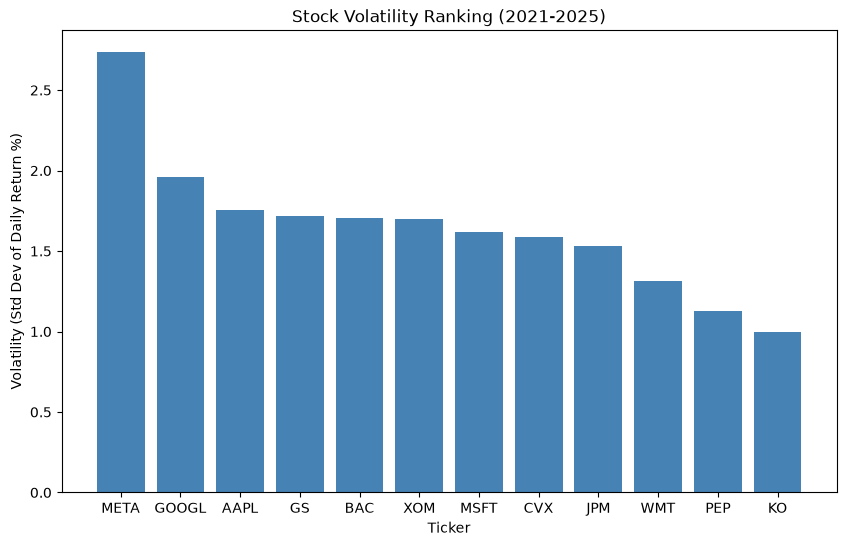

In [50]:
#Visualizaion for Stock Volatility ranking. 
result = pd.read_sql("""
    SELECT ticker, SQRT(AVG( (daily_return - avg_return) * (daily_return - avg_return) )) 
    AS volatility
    FROM (
        SELECT ticker, date, daily_return,
               AVG(daily_return) OVER (PARTITION BY ticker) AS avg_return
        FROM (
            SELECT ticker, date, close, prev_close,
                   (close - prev_close) / prev_close * 100 AS daily_return
            FROM (
                SELECT ticker, date, close,
                       LAG(close) OVER (PARTITION BY ticker ORDER BY date) AS prev_close
                FROM prices
            )
        )
    )
    GROUP BY ticker
    ORDER BY volatility DESC
""", conn)

plt.figure(figsize=(10, 6))
plt.bar(result['ticker'], result['volatility'], color='steelblue')
plt.xlabel('Ticker')
plt.ylabel('Volatility (Std Dev of Daily Return %)')
plt.title('Stock Volatility Ranking (2021-2025)')
plt.show()